In [1]:
# import the necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os

In [ ]:
# initialize initial learning rate, number of epochs and batch size
INIT_LR = 1e-4
EPOCHS = 10
BS = 32

In [3]:
#loading the dataset
dataset=r"/Users/jagadishkrishnan/Hope/10A_DL-Project-FaceMaskDetector/dataset"

In [ ]:
# load images from dataset
imagePaths = list(paths.list_images(dataset))
print("[INFO] loading images...", len(imagePaths))

[INFO] loading images... 3846


In [ ]:
# Empty Lists to store image data and labels separately
data = []
labels = []

# loop over the image paths
for imagePath in imagePaths:

	# extract class label from the filename (with mask and without mask)
	label = imagePath.split(os.path.sep)[-2]

	# load the input image (224x224) 
	image = load_img(imagePath, target_size=(224, 224))

    #Converting image to numpy array 
	image = img_to_array(image)
	
    #Normalise the input image using preprocess_input
	image = preprocess_input(image)

	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
print("[INFO] images loaded successfully!")

/Users/jagadishkrishnan/Hope/10A_DL-Project-FaceMaskDetector/.venv/lib/python3.13/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[INFO] images loaded successfully!


In [ ]:
# convert data and labels to NumPy arrays
data = np.array(data, dtype="float32")
labels = np.array(labels)

In [ ]:
#Label binarizer convert string labels into numeric form (with mask -> 1 & without mask -> 0)
lb = LabelBinarizer() 
labels = lb.fit_transform(labels)

#to_categorical convert numeric labels into one-hot encoded vectors (required when using softmax activation with categorical_crossentropy loss)
labels = to_categorical(labels) 

In [ ]:
# training and testing splits (80% - 20%)
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.20, stratify=labels, random_state=42)

In [9]:
# construct the training image generator for data augmentation
aug = ImageDataGenerator(
	rotation_range=20,
	zoom_range=0.15,
	width_shift_range=0.2,
	height_shift_range=0.2,
	shear_range=0.15,
	horizontal_flip=True,
	fill_mode="nearest")

In [ ]:
# load the MobileNetV2 network, ensuring the head FC layer sets are left off
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))

/var/folders/f5/j995pwn90q3c6pyc8ts6mh_00000gn/T/ipykernel_11937/4269477345.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False,


In [ ]:
# construct the head of the model that will be placed on top of the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

In [ ]:
# place the head FC model on top of the base model
model = Model(inputs=baseModel.input, outputs=headModel)

In [ ]:
# loop over all layers in the base model and freeze them so they will not be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

In [ ]:
# compile the model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

[INFO] compiling model...


In [16]:
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	aug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)

[INFO] training head...
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.8834 - loss: 0.2869 - val_accuracy: 0.9688 - val_loss: 0.0899
Epoch 2/10
 1/96 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.9688 - loss: 0.1090

/Users/jagadishkrishnan/Hope/10A_DL-Project-FaceMaskDetector/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9688 - loss: 0.1090 - val_accuracy: 0.9740 - val_loss: 0.0906
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.9616 - loss: 0.1071 - val_accuracy: 0.9753 - val_loss: 0.0656
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9688 - loss: 0.1294 - val_accuracy: 0.9740 - val_loss: 0.0653
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.9727 - loss: 0.0774 - val_accuracy: 0.9779 - val_loss: 0.0573
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9688 - loss: 0.1437 - val_accuracy: 0.9766 - val_loss: 0.0576
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 165ms/step - accuracy: 0.9790 - loss: 0.0585 - val_accuracy: 0.9844 - val_loss: 0.0500
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9688 - loss: 0.0695 - val_accuracy: 0.9844 - val_loss: 0.0499
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.9800 - loss: 0.0587 - val_accuracy: 0.9831 - val_

In [ ]:
print("[INFO] evaluating network...")

# Predict probabilities
predProbs = model.predict(testX, batch_size=BS)


[INFO] evaluating network...
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step


In [ ]:
# Convert predictions to class indices
predIdxs = np.argmax(predProbs, axis=1)

# Convert true labels from one-hot to class indices
trueIdxs = np.argmax(testY, axis=1)

# Sanity check (must match)
print("trueIdxs shape:", trueIdxs.shape)
print("predIdxs shape:", predIdxs.shape)


trueIdxs shape: (770,)
predIdxs shape: (770,)


In [19]:
print("\nClassification Report:")
print(classification_report(
    trueIdxs,
    predIdxs,
    target_names=lb.classes_,
    digits=4
))


Classification Report:
              precision    recall  f1-score   support

   with_mask     0.9870    0.9870    0.9870       384
without_mask     0.9870    0.9870    0.9870       386

    accuracy                         0.9870       770
   macro avg     0.9870    0.9870    0.9870       770
weighted avg     0.9870    0.9870    0.9870       770



In [21]:
# serialize the model to disk
print("[INFO] saving mask detector model...")
model.save("facemask_detector.keras")

[INFO] saving mask detector model...


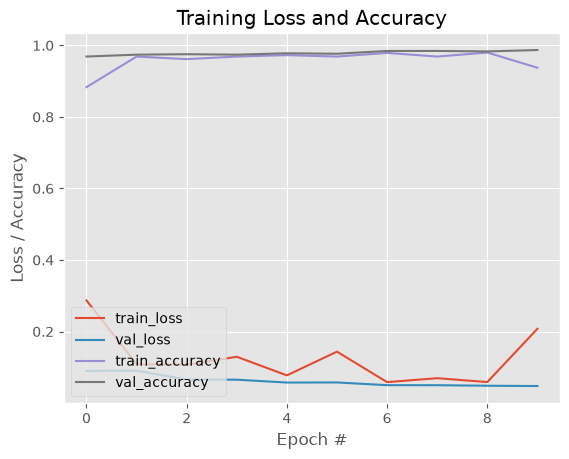

In [ ]:
# plot the training loss and accuracy curve
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_accuracy")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_accuracy")

plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss / Accuracy")
plt.legend(loc="lower left")
plt.show()